# 03 — EDA

## Cel

EDA (Exploratory Data Analysis) to wstępna analiza danych.

W tym notebooku:
- policzymy podstawowe statystyki,
- obejrzymy rozkład targetu,
- sprawdzimy kilka zależności,
- wykryjemy wartości odstające metodą IQR,
- zapiszemy krótkie wnioski.

Nie próbujemy analizować wszystkiego. Wybieramy tylko kilka najważniejszych cech.


## 1. Import bibliotek i wczytanie danych

In [12]:
# Path służy do tworzenia i obsługi ścieżek do plików i folderów.
from pathlib import Path

import numpy as np
import pandas as pd

# Matplotlib wykorzystam do tworzenia prostych wykresów.
import matplotlib.pyplot as plt


# Ścieżka do pełnego datasetu po transformacji.
DATA_PATH = Path("data/03_pelny_po_transformacji.csv")

# Nazwa kolumny, którą analizuję jako target.
TARGET = "interest_rate"


# Wczytuję dane przygotowane w poprzednim etapie.
df = pd.read_csv(DATA_PATH)

# Sprawdzam rozmiar datasetu.
print("Kształt:", df.shape)

# Wyświetlam pierwsze 5 wierszy.
df.head()


Kształt: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Pierwsze spojrzenie na dane do EDA

Wczytuję pełny dataset po transformacji, ponieważ podczas EDA chcę zachować
czytelne nazwy kategorii i mieć dostęp do większej liczby kolumn niż tylko tych,
które później trafią do modelu.

Na początku sprawdzam kształt danych oraz pierwsze wiersze, aby upewnić się,
że plik został poprawnie wczytany.

## 2. Statystyki opisowe

Na początku EDA sprawdzam podstawowe statystyki dla targetu oraz kilku
wybranych cech numerycznych.

Pozwala to szybko zobaczyć:
- typowe wartości,
- zakres danych,
- medianę i średnią,
- możliwe bardzo wysokie lub niskie wartości.

### 2.1. describe() dla wybranych kolumn

In [13]:
# Wybieram najważniejsze kolumny numeryczne,
# które wcześniej zostały wybrane do modelu.

kolumny_numeryczne = [
    TARGET,
    "loan_amount",
    "term",
    "annual_income",
    "debt_to_income",
    "emp_length",
]

# describe() pokazuje podstawowe statystyki:
# count, mean, std, min, kwartyle i max.
df[kolumny_numeryczne].describe().T


,count,mean,std,min,25%,50%,75%,max
interest_rate,10000.0,12.427524,5.001105,5.31,9.4300,11.98,15.05,30.94
loan_amount,10000.0,16361.922500,10301.956759,1000.00,8000.0000,14500.00,24000.00,40000.00
term,10000.0,43.272000,11.029877,36.00,36.0000,36.00,60.00,60.00
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.00,95000.00,2300000.00
debt_to_income,10000.0,19.304020,14.987074,0.00,11.0675,17.57,24.99,469.09
emp_length,10000.0,5.936000,3.549248,0.00,3.0000,6.00,10.00,10.00


### 2.2. Proste statystyki targetu z NumPy

In [14]:
# Dodatkowo obliczam kilka podstawowych statystyk
# dla targetu za pomocą NumPy.

srednia = np.mean(df[TARGET])
mediana = np.median(df[TARGET])
odchylenie_std = np.std(df[TARGET])
minimum = np.min(df[TARGET])
maksimum = np.max(df[TARGET])

print(f"Średnia: {srednia:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Odchylenie standardowe: {odchylenie_std:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"Maksimum: {maksimum:.2f}")

Średnia: 12.43
Mediana: 11.98
Odchylenie standardowe: 5.00
Minimum: 5.31
Maksimum: 30.94


### 2.3. Krótki komentarz do wyniku


### Wnioski ze statystyk opisowych

Target `interest_rate` ma średnią około 12.43% i medianę około 11.98%.
Wartości oprocentowania mieszczą się w zakresie od 5.31% do 30.94%.

Średnia jest nieco wyższa od mediany, co może sugerować występowanie
wyższych wartości oprocentowania po prawej stronie rozkładu.

W niektórych cechach, szczególnie `annual_income` i `debt_to_income`,
maksymalne wartości są znacznie większe od mediany. Może to wskazywać
na występowanie wartości odstających, które sprawdzę później metodą IQR.

## 3. Rozkład targetu

Histogram pokazuje, jak często występują poszczególne zakresy wartości targetu.

Dzięki temu mogę sprawdzić:
- gdzie znajduje się większość obserwacji,
- czy rozkład jest symetryczny,
- czy występują bardzo wysokie lub bardzo niskie wartości.

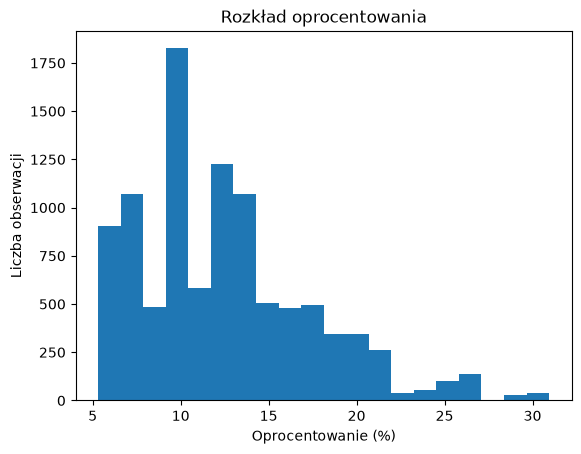

In [15]:
# Tworzę histogram dla kolumny targetowej interest_rate.
# bins=20 dzieli zakres wartości na 20 przedziałów.

plt.hist(
    df[TARGET],
    bins=20
)

# Dodaję tytuł oraz opisy osi.
plt.title("Rozkład oprocentowania")
plt.xlabel("Oprocentowanie (%)")
plt.ylabel("Liczba obserwacji")

# Wyświetlam wykres.
plt.show()


### Wnioski z histogramu

Rozkład `interest_rate` nie jest symetryczny i jest wyraźnie przesunięty w prawo.

Najwięcej pożyczek ma oprocentowanie w przedziale około 8–13%.
Wraz ze wzrostem oprocentowania liczba obserwacji stopniowo maleje.

Wysokie oprocentowanie, powyżej około 25%, występuje stosunkowo rzadko.
Rozkład ma więc dłuższy prawy ogon, co jest zgodne z wcześniejszą obserwacją,
że średnia oprocentowania jest nieco wyższa od mediany.

## 4. Zależności pomiędzy cechami a targetem

Teraz sprawdzam, czy wybrane cechy numeryczne mają widoczny związek
z oprocentowaniem pożyczki.

Do tego używam wykresu punktowego (`scatter plot`), na którym każda kropka
reprezentuje jedną obserwację.

### 4.1. loan_amount a interest_rate

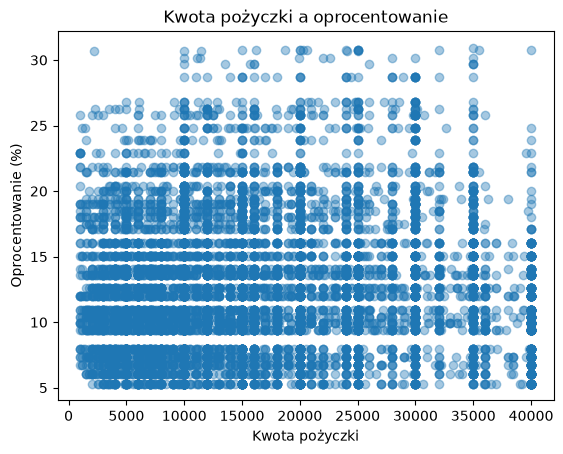

In [16]:
# Tworzę wykres punktowy pokazujący zależność
# między kwotą pożyczki a oprocentowaniem.

plt.scatter(
    df["loan_amount"],
    df[TARGET],
    alpha=0.4
)

plt.title("Kwota pożyczki a oprocentowanie")
plt.xlabel("Kwota pożyczki")
plt.ylabel("Oprocentowanie (%)")

plt.show()


### 4.2. debt_to_income a interest_rate

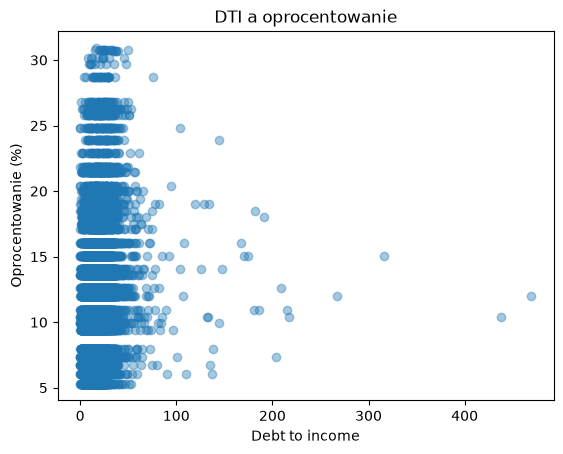

In [17]:
# Tworzę drugi wykres punktowy.
# Tym razem sprawdzam zależność między DTI
# a oprocentowaniem pożyczki.

plt.scatter(
    df["debt_to_income"],
    df[TARGET],
    alpha=0.4
)

plt.title("DTI a oprocentowanie")
plt.xlabel("Debt to income")
plt.ylabel("Oprocentowanie (%)")

plt.show()

### Wnioski z wykresów

Na wykresie `loan_amount` a `interest_rate` nie widać wyraźnej zależności liniowej.
Dla podobnych kwot pożyczki występują zarówno niskie, jak i wysokie wartości
oprocentowania. Sama kwota pożyczki prawdopodobnie nie wystarcza więc do
wyjaśnienia wysokości oprocentowania.

W przypadku `debt_to_income` większość obserwacji znajduje się przy stosunkowo
niskich wartościach DTI. Również tutaj nie widać wyraźnej zależności liniowej
z oprocentowaniem.

Na wykresie DTI widoczne są pojedyncze bardzo wysokie wartości, znacznie
oddalone od większości obserwacji. Mogą to być wartości odstające, które
sprawdzę dokładniej w kolejnym etapie za pomocą metody IQR.

## 5. Wartości odstające — metoda IQR

Wartości odstające to obserwacje znacznie różniące się od większości danych.

Do ich wykrycia używam metody IQR (Interquartile Range), czyli rozstępu
międzykwartylowego.

IQR obliczam jako różnicę pomiędzy trzecim i pierwszym kwartylem:

`IQR = Q3 - Q1`

Za potencjalne wartości odstające uznaję wartości mniejsze od:

`Q1 - 1.5 * IQR`

lub większe od:

`Q3 + 1.5 * IQR`.

In [18]:
# Obliczam pierwszy kwartyl Q1, czyli wartość,
# poniżej której znajduje się 25% obserwacji.
Q1 = df["debt_to_income"].quantile(0.25)

# Obliczam trzeci kwartyl Q3, czyli wartość,
# poniżej której znajduje się 75% obserwacji.
Q3 = df["debt_to_income"].quantile(0.75)

# IQR to różnica pomiędzy trzecim i pierwszym kwartylem.
IQR = Q3 - Q1

# Wyznaczam dolną i górną granicę wartości odstających.
dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Dolna granica: {dolna_granica:.2f}")
print(f"Górna granica: {gorna_granica:.2f}")


Q1: 11.07
Q3: 24.99
IQR: 13.92
Dolna granica: -9.82
Górna granica: 45.87


Następnie wykrywamy outliery:

In [19]:
# Tworzę maskę logiczną.
# True oznacza obserwację znajdującą się poza granicami IQR.

maska_outlierow = (
    (df["debt_to_income"] < dolna_granica)
    | (df["debt_to_income"] > gorna_granica)
)

# Zliczam liczbę wartości odstających.
liczba_outlierow = maska_outlierow.sum()

print("Liczba wartości odstających:", liczba_outlierow)
print(
    "Procent wartości odstających:",
    round(liczba_outlierow / len(df) * 100, 2),
    "%"
)

Liczba wartości odstających: 221
Procent wartości odstających: 2.21 %


In [20]:
# Wyświetlam kilka obserwacji uznanych przez metodę IQR
# za wartości odstające.

df.loc[
    maska_outlierow,
    ["debt_to_income", TARGET]
].head(10)

,debt_to_income,interest_rate
4,57.96,14.07
99,49.58,20.00
267,74.38,6.72
327,128.61,19.03
349,204.13,7.35
367,80.75,9.93
433,92.67,15.05
468,55.61,9.93
516,469.09,11.99
533,75.45,28.72


/tmp/ipykernel_177514/816579113.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


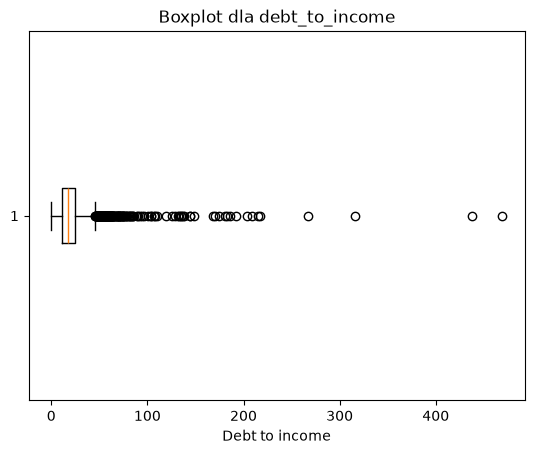

In [21]:
# Boxplot pozwala wizualnie zobaczyć rozkład danych
# oraz wartości znajdujące się daleko poza większością obserwacji.

plt.boxplot(
    df["debt_to_income"],
    vert=False
)

plt.title("Boxplot dla debt_to_income")
plt.xlabel("Debt to income")

plt.show()

### Wnioski z analizy wartości odstających

Metoda IQR wskazała część obserwacji `debt_to_income` jako wartości odstające.

Na wykresie również widoczne są pojedyncze bardzo wysokie wartości DTI,
znacznie oddalone od większości obserwacji.

Nie usuwam ich automatycznie, ponieważ wysoka wartość DTI może być rzeczywistą
informacją o sytuacji finansowej klienta, a nie błędem w danych.

Pozostawiam więc te obserwacje w datasecie.

## 6. Wnioski

Na podstawie przeprowadzonej analizy można zauważyć, że:

- większość wartości `interest_rate` znajduje się w niższym i średnim zakresie,
  a rozkład ma dłuższy prawy ogon,
- `loan_amount` nie pokazuje wyraźnej zależności liniowej z oprocentowaniem,
- `debt_to_income` również nie wykazuje silnej zależności liniowej z targetem,
- w `debt_to_income` występują wartości odstające,
- wartości odstających nie usuwam automatycznie, ponieważ mogą być prawidłowymi
  obserwacjami, a nie błędami danych.

Dane są gotowe do przejścia do etapu budowy modelu regresji liniowej.
